# UPI Fraud Detection — Phase 2: Model Training & Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

## Step 1: Load Processed Dataset

In [2]:
BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_PATH  = os.path.join(BASE_DIR, 'data', 'processed_fraud.csv')
MODEL_DIR  = os.path.join(BASE_DIR, 'models')

df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

✅ Dataset loaded: 26,393 rows × 61 columns


,amount,device_id,location,session_duration,authentication_attempts,receiver_account_age,transaction_amount_vs_sender_history,geographic_disparity,transaction_time_of_day,merchant_category_code,...,day_of_week,is_weekend,is_night,month,amount_log,is_high_value,amount_zscore,user_tx_count,user_tx_mean_amount,amount_vs_user_mean
0,1960.754748,313,8126,234,1,350,1.273830,11080.796800,23,1,...,2.0,0,0,5.0,7.581595,0,-0.507754,9,5976.411457,0.328027
1,4593.854621,3676,3064,98,1,29,4.946103,7582.484261,14,1,...,NaN,0,0,NaN,8.432692,0,-0.047463,8,2837.500598,1.618409
2,1949.587163,355,11750,100,1,166,0.871469,3398.589394,2,3,...,NaN,0,0,NaN,7.575886,0,-0.509706,7,4314.227790,0.451792
3,2825.569899,1098,11341,145,1,360,21.445879,10979.289660,7,5,...,2.0,0,0,5.0,7.946819,0,-0.356576,6,3080.960178,0.916809
4,6509.628443,4549,4999,13,1,0,0.990145,9626.410055,3,4,...,NaN,0,0,NaN,8.781191,0,0.287433,3,5050.887208,1.288554


## Step 2: Prepare Features & Target

In [3]:
target_col = 'is_fraud'

# Keep only genuine input features
keep_cols = [
    'amount', 'transaction_type', 'device_id', 'location',
    'session_duration', 'authentication_status',
    'pin_entry_method', 'authentication_attempt_count',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'month',
    'amount_log', 'is_high_value', 'amount_zscore',
    'user_tx_count', 'user_tx_mean_amount', 'amount_vs_user_mean'
]

keep_cols = [c for c in keep_cols if c in df.columns and c != target_col]

X = df[keep_cols]
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

import json
feature_names = list(X.columns)
with open(os.path.join(MODEL_DIR, 'features.json'), 'w') as f:
    json.dump(feature_names, f)

print(f"✅ Features used : {len(feature_names)}")
print(f"✅ Feature list  : {feature_names}")
print(f"✅ Fraud rate    : {y.mean()*100:.2f}%")

✅ Features used : 18
✅ Feature list  : ['amount', 'transaction_type', 'device_id', 'location', 'session_duration', 'pin_entry_method', 'authentication_attempt_count', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'month', 'amount_log', 'is_high_value', 'amount_zscore', 'user_tx_count', 'user_tx_mean_amount', 'amount_vs_user_mean']
✅ Fraud rate    : 17.22%


## Step 3: Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Train set : {X_train.shape[0]:,} rows")
print(f"✅ Test set  : {X_test.shape[0]:,} rows")
print(f"\nTrain fraud rate : {y_train.mean()*100:.2f}%")
print(f"Test  fraud rate : {y_test.mean()*100:.2f}%")

✅ Train set : 21,114 rows
✅ Test set  : 5,279 rows

Train fraud rate : 17.22%
Test  fraud rate : 17.22%


In [5]:
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)
X_train = X_train.replace([np.inf, -np.inf], 0)
X_test  = X_test.replace([np.inf, -np.inf], 0)

np.random.seed(42)
noise = np.random.normal(0, 0.01, X_train.shape)
X_train = pd.DataFrame(X_train.values + noise, columns=X_train.columns)

print(f"NaN after fix : {X_train.isna().sum().sum()}")
print(f"✅ Ready for training")

NaN after fix : 0
✅ Ready for training


## Step 4: Train All 4 Models

In [6]:
# Calculate class weight for imbalance
fraud_ratio = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight (XGBoost) : {fraud_ratio:.2f}")

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=fraud_ratio,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

print("✅ Models defined")

scale_pos_weight (XGBoost) : 4.81
✅ Models defined


In [7]:
# Train all models and collect results
results = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train, y_train)
    
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_proba)
    }
    print(f"✅ AUC = {results[name]['roc_auc']:.4f}")

print("\n✅ All models trained")

Training Logistic Regression... ✅ AUC = 0.9491
Training Decision Tree... ✅ AUC = 0.9438
Training Random Forest... ✅ AUC = 0.9570
Training XGBoost... ✅ AUC = 0.9591

✅ All models trained


## Step 5: Compare Model Performance

In [8]:
# Build comparison table
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall'   : round(r['recall'],    4),
        'F1 Score' : round(r['f1'],        4),
        'ROC-AUC'  : round(r['roc_auc'],   4)
    }
    for name, r in results.items()
}).T

print("MODEL PERFORMANCE COMPARISON")
print("=" * 65)
display(metrics_df.sort_values('ROC-AUC', ascending=False))

MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.9704,0.9542,0.8702,0.9102,0.9591
Random Forest,0.9712,0.9522,0.8768,0.9129,0.9570
Logistic Regression,0.9581,0.9009,0.8504,0.8749,0.9491
Decision Tree,0.9655,0.9145,0.8823,0.8981,0.9438


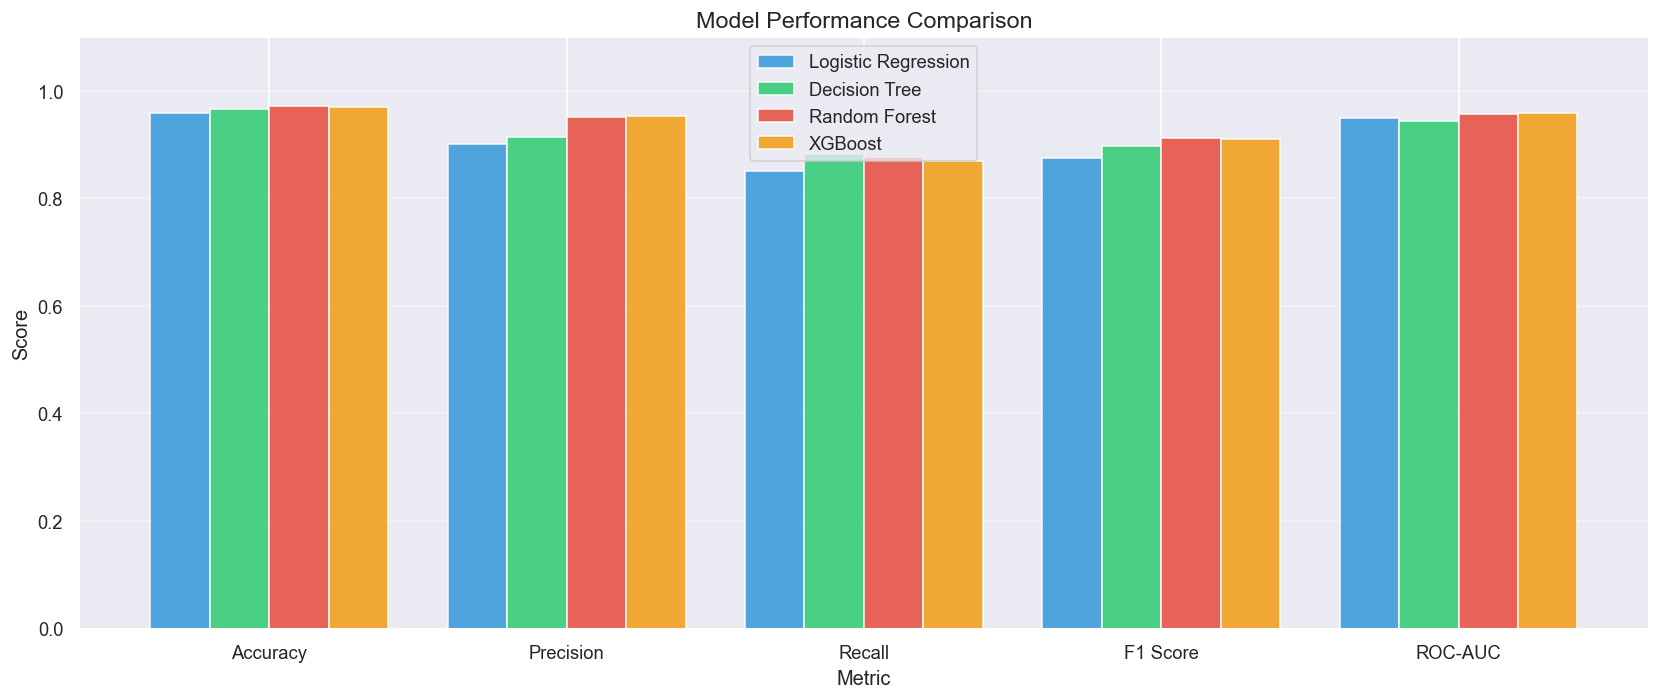

In [9]:
# Bar chart comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, r) in enumerate(results.items()):
    vals = [round(r['accuracy'],4), round(r['precision'],4),
            round(r['recall'],4), round(r['f1'],4), round(r['roc_auc'],4)]
    bars = ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'model_comparison.png'), dpi=120)
plt.show()

## Step 6: ROC Curves

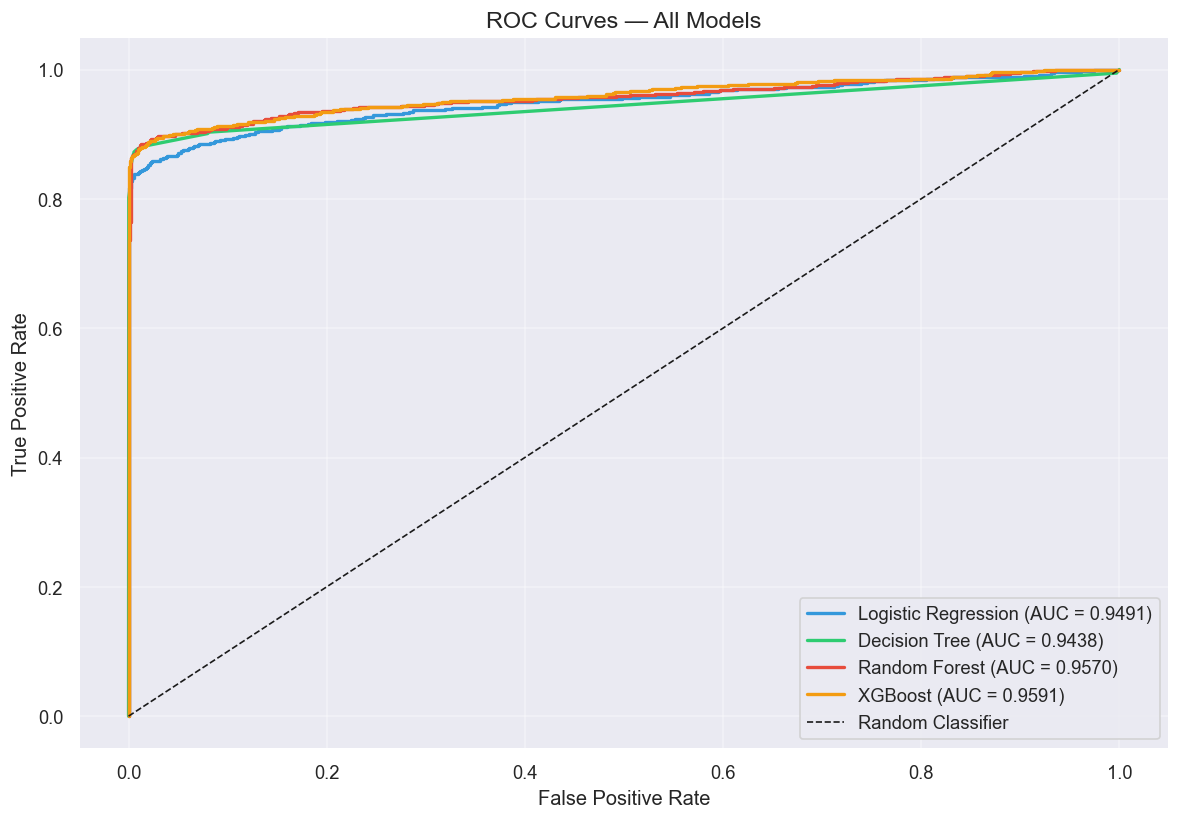

In [10]:
plt.figure(figsize=(10, 7))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {r['roc_auc']:.4f})")

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'roc_curves.png'), dpi=120)
plt.show()

## Step 7: Confusion Matrices

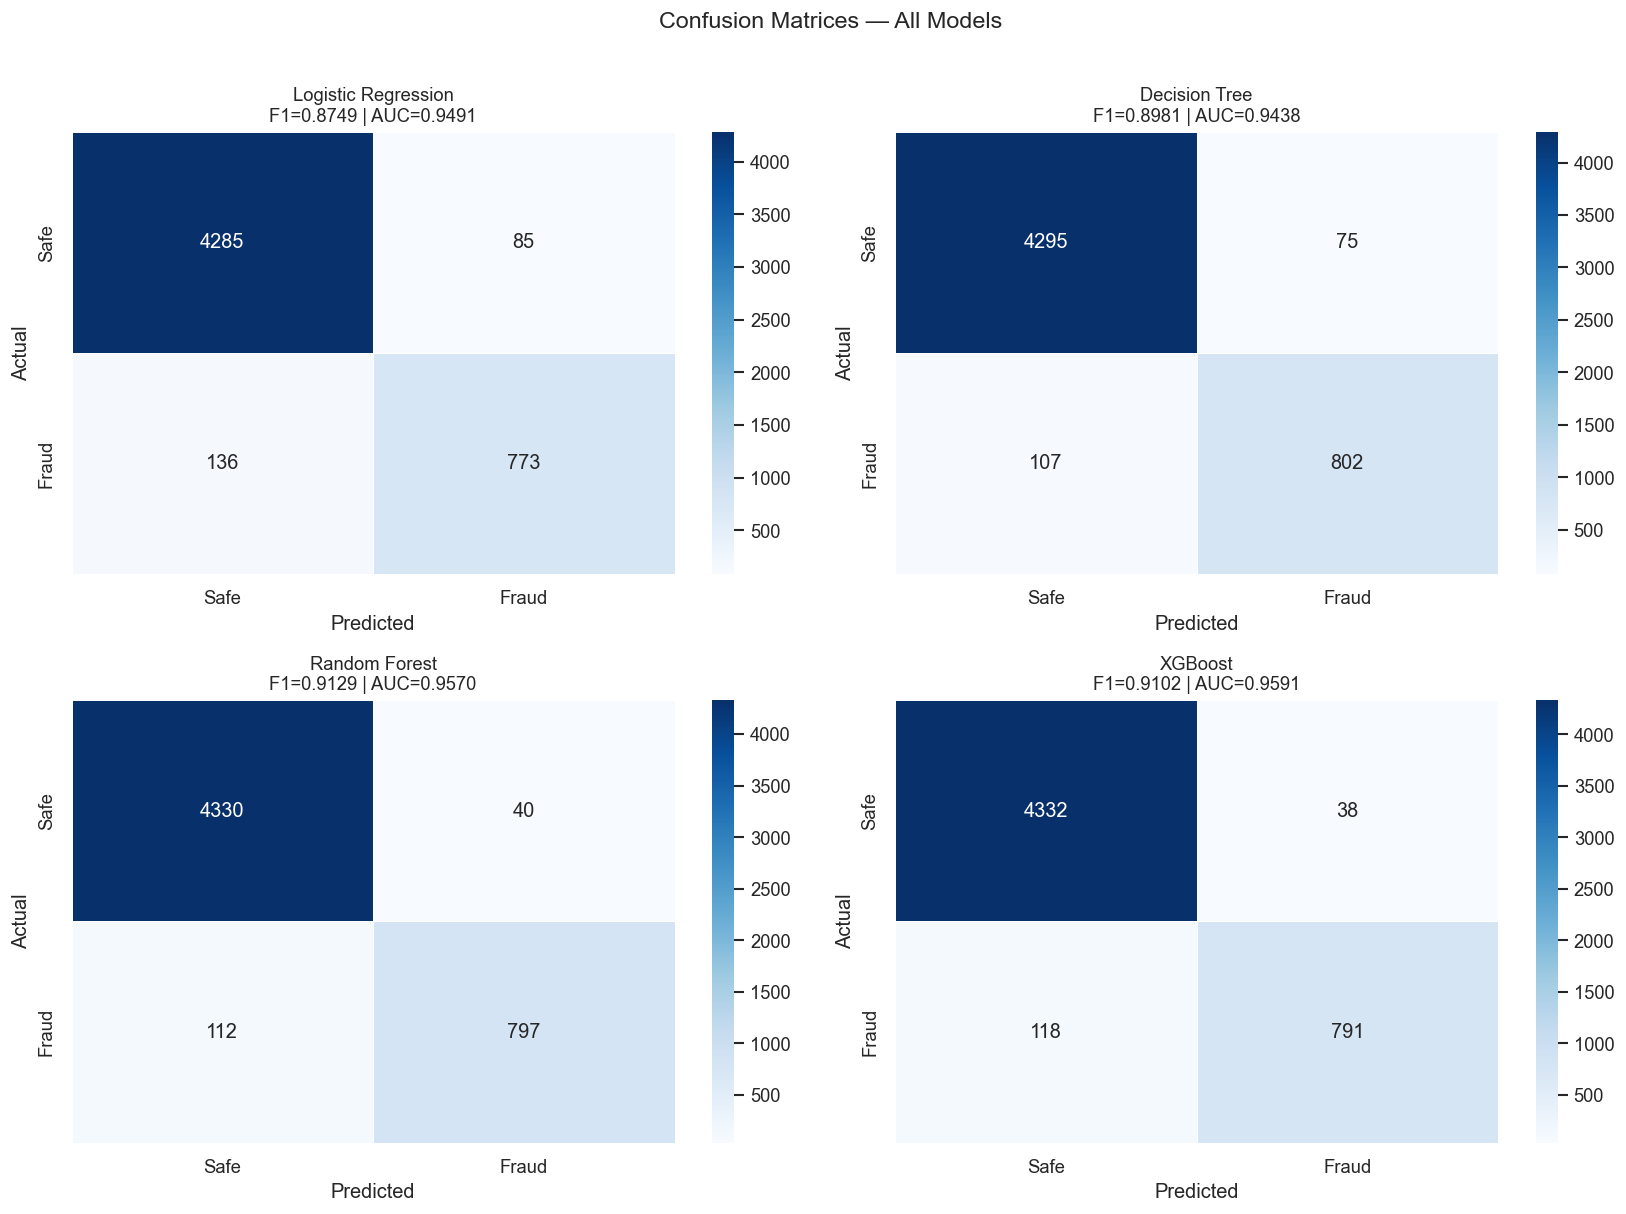

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[i], linewidths=0.5,
                xticklabels=['Safe', 'Fraud'],
                yticklabels=['Safe', 'Fraud'])
    axes[i].set_title(f'{name}\nF1={r["f1"]:.4f} | AUC={r["roc_auc"]:.4f}', fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrices.png'), dpi=120)
plt.show()

## Step 8: Feature Importance (XGBoost)

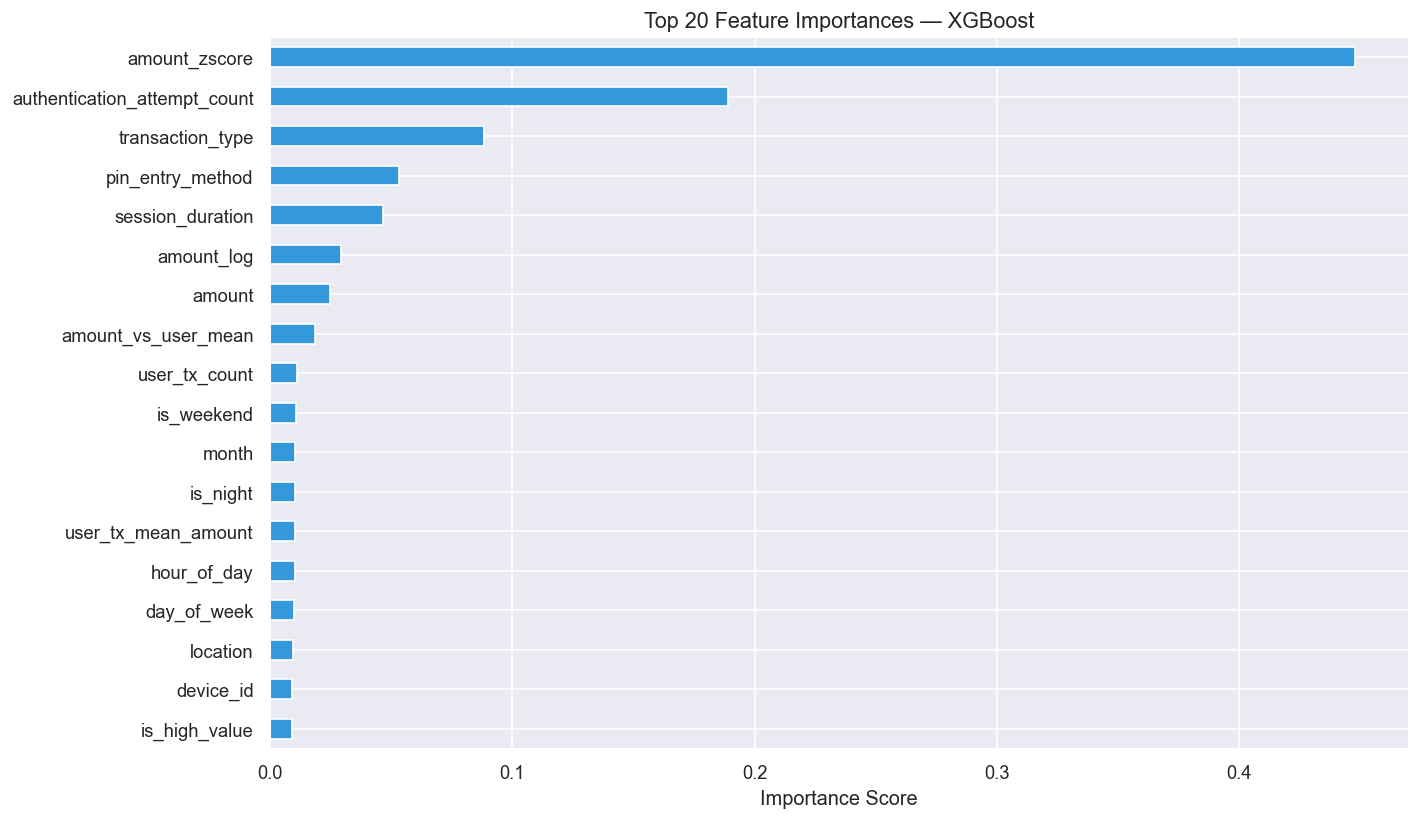


Top 10 most important features:
amount_zscore                   0.447464
authentication_attempt_count    0.188962
transaction_type                0.088261
pin_entry_method                0.053459
session_duration                0.046805
amount_log                      0.029251
amount                          0.024848
amount_vs_user_mean             0.018838
user_tx_count                   0.011336
is_weekend                      0.010802


In [12]:
xgb_model = results['XGBoost']['model']
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
top20.sort_values().plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Top 20 Feature Importances — XGBoost', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'feature_importance.png'), dpi=120)
plt.show()

print("\nTop 10 most important features:")
print(top20.head(10).to_string())

## Step 9: Anomaly Detection (Isolation Forest)

In [13]:
print("Training Isolation Forest...")
iso_forest = IsolationForest(
    contamination=0.17,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)

iso_preds = iso_forest.predict(X_test)
iso_labels = np.where(iso_preds == -1, 1, 0)

print(f"✅ Isolation Forest trained")
print(f"\nAnomalies detected : {iso_labels.sum():,}")
print(f"Actual fraud count : {y_test.sum():,}")
print(f"\nAnomaly vs Actual Fraud overlap:")
print(pd.crosstab(y_test, iso_labels,
                  rownames=['Actual'], colnames=['Predicted Anomaly']))

iso_f1  = f1_score(y_test, iso_labels)
iso_auc = roc_auc_score(y_test, iso_labels)
print(f"\nIsolation Forest F1  : {iso_f1:.4f}")
print(f"Isolation Forest AUC : {iso_auc:.4f}")

Training Isolation Forest...
✅ Isolation Forest trained

Anomalies detected : 653
Actual fraud count : 909

Anomaly vs Actual Fraud overlap:
Predicted Anomaly     0    1
Actual                      
0                  4307   63
1                   319  590

Isolation Forest F1  : 0.7554
Isolation Forest AUC : 0.8173


## Step 10: Save Best Model

In [14]:
# Save XGBoost model (best performer)
best_model = results['XGBoost']['model']

joblib.dump(best_model, os.path.join(MODEL_DIR, 'xgboost_model.pkl'))
joblib.dump(scaler,     os.path.join(MODEL_DIR, 'scaler.pkl'))
joblib.dump(iso_forest, os.path.join(MODEL_DIR, 'isolation_forest.pkl'))

print("✅ Models saved:")
print(f"   → {MODEL_DIR}/xgboost_model.pkl")
print(f"   → {MODEL_DIR}/scaler.pkl")
print(f"   → {MODEL_DIR}/isolation_forest.pkl")
print(f"   → {MODEL_DIR}/features.json")

✅ Models saved:
   → d:\upi-fraud-detection\ml\models/xgboost_model.pkl
   → d:\upi-fraud-detection\ml\models/scaler.pkl
   → d:\upi-fraud-detection\ml\models/isolation_forest.pkl
   → d:\upi-fraud-detection\ml\models/features.json


## Step 11: Final Summary

In [15]:
best_name = max(results, key=lambda x: results[x]['roc_auc'])
best      = results[best_name]

print("=" * 55)
print("  PHASE 2 SUMMARY — MODEL TRAINING COMPLETE")
print("=" * 55)
print(f"  Best model     : {best_name}")
print(f"  Accuracy       : {best['accuracy']*100:.2f}%")
print(f"  Precision      : {best['precision']*100:.2f}%")
print(f"  Recall         : {best['recall']*100:.2f}%")
print(f"  F1 Score       : {best['f1']*100:.2f}%")
print(f"  ROC-AUC        : {best['roc_auc']:.4f}")
print("=" * 55)
print(f"\n✅ Phase 2 Complete — Ready for Phase 3: FastAPI Backend")

  PHASE 2 SUMMARY — MODEL TRAINING COMPLETE
  Best model     : XGBoost
  Accuracy       : 97.04%
  Precision      : 95.42%
  Recall         : 87.02%
  F1 Score       : 91.02%
  ROC-AUC        : 0.9591

✅ Phase 2 Complete — Ready for Phase 3: FastAPI Backend


In [16]:
# Check feature correlation with target
target_col = 'is_fraud'
df_check = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed_fraud.csv'))

correlations = df_check.corr()[target_col].abs().sort_values(ascending=False)
print("Top 20 features correlated with target:")
print(correlations.head(20).to_string())

Top 20 features correlated with target:
is_fraud                             1.000000
pin_entry_method                     0.523787
authentication_attempt_count         0.518601
is_high_value                        0.499841
amount                               0.477188
amount_zscore                        0.477188
input_timing_consistency             0.465539
authentication_attempts              0.438320
amount_vs_user_mean                  0.435543
receiver_account_age                 0.424979
amount_log                           0.404434
input_pause_patterns                 0.398484
session_source                       0.376757
handle_typo_analysis                 0.374188
handle_to_description_consistency    0.374188
background_data_usage                0.373664
authorization_method                 0.370563
request_description_keywords         0.370303
request_description                  0.370303
transaction_type                     0.370303


In [17]:
# Find ALL columns with correlation > 0.7 with target (definitely leaky)
df_check = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed_fraud.csv'))
correlations = df_check.corr()['is_fraud'].abs().sort_values(ascending=False)
high_corr = correlations[correlations > 0.5]
print("Columns with correlation > 0.5 with is_fraud:")
print(high_corr.to_string())

Columns with correlation > 0.5 with is_fraud:
is_fraud                        1.000000
pin_entry_method                0.523787
authentication_attempt_count    0.518601
